## 💡 Ethereum Fraud Detection System
Developed a **Machine Learning model** to identify **fraudulent Ethereum transactions** by analyzing transaction patterns and behavioral data.  
The goal is to proactively detect suspicious activities and enhance transaction security in blockchain systems.


In [66]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# !pip install category_encoders-> for from category_encoders import TargetEncoder

from sklearn.model_selection import train_test_split
from category_encoders import TargetEncoder
from sklearn.ensemble import IsolationForest
from sklearn.manifold import TSNE

In [63]:
!pip install category_encoders

## 1. Data Loading 


In [67]:
df = pd.read_csv("C:/Users/Asus/Downloads/transaction_dataset/transaction_dataset.csv")

## 2. Exploratory Data Analysis (EDA)
## Inspecting the first few rows and general structure

In [68]:
df.head()

,Unnamed: 0,Index,Address,FLAG,Avg min between sent tnx,Avg min between received tnx,Time Diff between first and last (Mins),Sent tnx,Received Tnx,Number of Created Contracts,...,ERC20 min val sent,ERC20 max val sent,ERC20 avg val sent,ERC20 min val sent contract,ERC20 max val sent contract,ERC20 avg val sent contract,ERC20 uniq sent token name,ERC20 uniq rec token name,ERC20 most sent token type,ERC20_most_rec_token_type
0,0,1,0x00009277775ac7d0d59eaad8fee3d10ac6c805e8,0,844.26,1093.71,704785.63,721,89,0,...,0.000000,1.683100e+07,271779.920000,0.0,0.0,0.0,39.0,57.0,Cofoundit,Numeraire
1,1,2,0x0002b44ddb1476db43c868bd494422ee4c136fed,0,12709.07,2958.44,1218216.73,94,8,0,...,2.260809,2.260809e+00,2.260809,0.0,0.0,0.0,1.0,7.0,Livepeer Token,Livepeer Token
2,2,3,0x0002bda54cb772d040f779e88eb453cac0daa244,0,246194.54,2434.02,516729.30,2,10,0,...,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,8.0,None,XENON
3,3,4,0x00038e6ba2fd5c09aedb96697c8d7b8fa6632e5e,0,10219.60,15785.09,397555.90,25,9,0,...,100.000000,9.029231e+03,3804.076893,0.0,0.0,0.0,1.0,11.0,Raiden,XENON
4,4,5,0x00062d1dd1afb6fb02540ddad9cdebfe568e0d89,0,36.61,10707.77,382472.42,4598,20,1,...,0.000000,4.500000e+04,13726.659220,0.0,0.0,0.0,6.0,27.0,StatusNetwork,EOS


In [69]:
df.tail()

,Unnamed: 0,Index,Address,FLAG,Avg min between sent tnx,Avg min between received tnx,Time Diff between first and last (Mins),Sent tnx,Received Tnx,Number of Created Contracts,...,ERC20 min val sent,ERC20 max val sent,ERC20 avg val sent,ERC20 min val sent contract,ERC20 max val sent contract,ERC20 avg val sent contract,ERC20 uniq sent token name,ERC20 uniq rec token name,ERC20 most sent token type,ERC20_most_rec_token_type
9836,9836,2175,0xff481ca14e6c16b79fc8ab299b4d2387ec8ecdd2,1,12635.10,631.39,58748.48,4,13,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,,GSENetwork
9837,9837,2176,0xff718805bb9199ebf024ab6acd333e603ad77c85,1,0.00,0.00,0.00,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,,Blockwell say NOTSAFU
9838,9838,2177,0xff8e6af02d41a576a0c82f7835535193e1a6bccc,1,2499.44,2189.29,261601.88,67,43,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,,Free BOB Tokens - BobsRepair.com
9839,9839,2178,0xffde23396d57e10abf58bd929bb1e856c7718218,1,0.00,0.00,0.00,0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9840,9840,2179,0xd624d046edbdef805c5e4140dce5fb5ec1b39a3c,1,37242.70,149.56,670817.33,18,3,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,42.0,,INS Promo1


In [70]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9841 entries, 0 to 9840
Data columns (total 51 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   Unnamed: 0                                            9841 non-null   int64  
 1   Index                                                 9841 non-null   int64  
 2   Address                                               9841 non-null   object 
 3   FLAG                                                  9841 non-null   int64  
 4   Avg min between sent tnx                              9841 non-null   float64
 5   Avg min between received tnx                          9841 non-null   float64
 6   Time Diff between first and last (Mins)               9841 non-null   float64
 7   Sent tnx                                              9841 non-null   int64  
 8   Received Tnx                                          9841

In [71]:
print(f"Number of rows in DataFrame is {df.shape[0]}")
print(f"Number of columns in DataFrame is {df.shape[1]}")

Number of rows in DataFrame is 9841
Number of columns in DataFrame is 51


In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9841 entries, 0 to 9840
Data columns (total 51 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   Unnamed: 0                                            9841 non-null   int64  
 1   Index                                                 9841 non-null   int64  
 2   Address                                               9841 non-null   object 
 3   FLAG                                                  9841 non-null   int64  
 4   Avg min between sent tnx                              9841 non-null   float64
 5   Avg min between received tnx                          9841 non-null   float64
 6   Time Diff between first and last (Mins)               9841 non-null   float64
 7   Sent tnx                                              9841 non-null   int64  
 8   Received Tnx                                          9841

### Checking for missing values

In [73]:
print("Number of NaN values in each columns:\n\n", df.isnull().sum())

Number of NaN values in each columns:

 Unnamed: 0                                                0
Index                                                     0
Address                                                   0
FLAG                                                      0
Avg min between sent tnx                                  0
Avg min between received tnx                              0
Time Diff between first and last (Mins)                   0
Sent tnx                                                  0
Received Tnx                                              0
Number of Created Contracts                               0
Unique Received From Addresses                            0
Unique Sent To Addresses                                  0
min value received                                        0
max value received                                        0
avg val received                                          0
min val sent                                              0


In [74]:
print(f"Total number of NaN values is {df.isnull().sum().sum()}")

Total number of NaN values is 20759


### Checking for duplicate entries

In [75]:
print(f"Number of duplicated values in Index columns is {df.duplicated(subset='Index').sum()}")

Number of duplicated values in Index columns is 5112


In [76]:
print(f"Number of duplicated values is {df.duplicated().sum()}")

Number of duplicated values is 0


## 3. Data Cleaning
### Standardizing column names (removing spaces and adding underscores)

In [77]:
df.columns = df.columns.str.strip().str.replace(r'\b\s+\b', '_', regex=True)
df.columns

Index(['Unnamed: 0', 'Index', 'Address', 'FLAG', 'Avg_min_between_sent_tnx',
       'Avg_min_between_received_tnx',
       'Time_Diff_between_first_and_last (Mins)', 'Sent_tnx', 'Received_Tnx',
       'Number_of_Created_Contracts', 'Unique_Received_From_Addresses',
       'Unique_Sent_To_Addresses', 'min_value_received', 'max_value_received',
       'avg_val_received', 'min_val_sent', 'max_val_sent', 'avg_val_sent',
       'min_value_sent_to_contract', 'max_val_sent_to_contract',
       'avg_value_sent_to_contract',
       'total_transactions (including_tnx_to_create_contract',
       'total_Ether_sent', 'total_ether_received',
       'total_ether_sent_contracts', 'total_ether_balance', 'Total_ERC20_tnxs',
       'ERC20_total_Ether_received', 'ERC20_total_ether_sent',
       'ERC20_total_Ether_sent_contract', 'ERC20_uniq_sent_addr',
       'ERC20_uniq_rec_addr', 'ERC20_uniq_sent_addr.1',
       'ERC20_uniq_rec_contract_addr', 'ERC20_avg_time_between_sent_tnx',
       'ERC20_avg_time_be

In [78]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,9841.0,4.920000e+03,2.840996e+03,0.00,2460.000000,4.920000e+03,7380.000000,9.840000e+03
Index,9841.0,1.815050e+03,1.222622e+03,1.00,821.000000,1.641000e+03,2601.000000,4.729000e+03
FLAG,9841.0,2.214206e-01,4.152241e-01,0.00,0.000000,0.000000e+00,0.000000,1.000000e+00
Avg_min_between_sent_tnx,9841.0,5.086879e+03,2.148655e+04,0.00,0.000000,1.734000e+01,565.470000,4.302877e+05
Avg_min_between_received_tnx,9841.0,8.004851e+03,2.308171e+04,0.00,0.000000,5.097700e+02,5480.390000,4.821755e+05
Time_Diff_between_first_and_last (Mins),9841.0,2.183333e+05,3.229379e+05,0.00,316.930000,4.663703e+04,304070.980000,1.954861e+06
Sent_tnx,9841.0,1.159317e+02,7.572264e+02,0.00,1.000000,3.000000e+00,11.000000,1.000000e+04
Received_Tnx,9841.0,1.637009e+02,9.408366e+02,0.00,1.000000,4.000000e+00,27.000000,1.000000e+04
Number_of_Created_Contracts,9841.0,3.729702e+00,1.414456e+02,0.00,0.000000,0.000000e+00,0.000000,9.995000e+03
Unique_Received_From_Addresses,9841.0,3.036094e+01,2.986211e+02,0.00,1.000000,2.000000e+00,5.000000,9.999000e+03


In [79]:
# Show number of values in each class in percent
df['FLAG'].value_counts(normalize=True) * 100

0    77.857941
1    22.142059
Name: FLAG, dtype: float64

In [80]:
df[df.duplicated(subset='Index')]['FLAG'].value_counts(normalize=True) * 100

0    57.374804
1    42.625196
Name: FLAG, dtype: float64

In [81]:
df.drop(columns=['Unnamed: 0', 'Index', 'Address'], axis=0, inplace=True)

In [82]:
df

,FLAG,Avg_min_between_sent_tnx,Avg_min_between_received_tnx,Time_Diff_between_first_and_last (Mins),Sent_tnx,Received_Tnx,Number_of_Created_Contracts,Unique_Received_From_Addresses,Unique_Sent_To_Addresses,min_value_received,...,ERC20_min_val_sent,ERC20_max_val_sent,ERC20_avg_val_sent,ERC20_min_val_sent_contract,ERC20_max_val_sent_contract,ERC20_avg_val_sent_contract,ERC20_uniq_sent_token_name,ERC20_uniq_rec_token_name,ERC20_most_sent_token_type,ERC20_most_rec_token_type
0,0,844.26,1093.71,704785.63,721,89,0,40,118,0.000000,...,0.000000,1.683100e+07,271779.920000,0.0,0.0,0.0,39.0,57.0,Cofoundit,Numeraire
1,0,12709.07,2958.44,1218216.73,94,8,0,5,14,0.000000,...,2.260809,2.260809e+00,2.260809,0.0,0.0,0.0,1.0,7.0,Livepeer Token,Livepeer Token
2,0,246194.54,2434.02,516729.30,2,10,0,10,2,0.113119,...,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,8.0,None,XENON
3,0,10219.60,15785.09,397555.90,25,9,0,7,13,0.000000,...,100.000000,9.029231e+03,3804.076893,0.0,0.0,0.0,1.0,11.0,Raiden,XENON
4,0,36.61,10707.77,382472.42,4598,20,1,7,19,0.000000,...,0.000000,4.500000e+04,13726.659220,0.0,0.0,0.0,6.0,27.0,StatusNetwork,EOS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9836,1,12635.10,631.39,58748.48,4,13,0,11,4,0.004082,...,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,2.0,,GSENetwork
9837,1,0.00,0.00,0.00,0,0,0,0,0,0.000000,...,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,1.0,,Blockwell say NOTSAFU
9838,1,2499.44,2189.29,261601.88,67,43,0,31,44,0.001078,...,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,5.0,,Free BOB Tokens - BobsRepair.com
9839,1,0.00,0.00,0.00,0,1,0,1,0,0.500000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [83]:
categories = df.select_dtypes(include=['object']).columns

for i in categories:
    print(f"The number of unique values in {i} is {df[i].nunique()} and it has {df[i].isnull().sum()} NaN values")

The number of unique values in ERC20_most_sent_token_type is 305 and it has 841 NaN values
The number of unique values in ERC20_most_rec_token_type is 467 and it has 851 NaN values


In [84]:
numeric = df.select_dtypes(include=['number']).columns
constant_var = [i for i in numeric if df[i].var() == 0]
print(f"Number of features that have constant value is {len(constant_var)}")
constant_var

Number of features that have constant value is 7


['ERC20_avg_time_between_sent_tnx',
 'ERC20_avg_time_between_rec_tnx',
 'ERC20_avg_time_between_rec_2_tnx',
 'ERC20_avg_time_between_contract_tnx',
 'ERC20_min_val_sent_contract',
 'ERC20_max_val_sent_contract',
 'ERC20_avg_val_sent_contract']

In [85]:
# Drop constant variance features
df.drop(columns=constant_var, axis=0, inplace=True)

In [86]:
df

,FLAG,Avg_min_between_sent_tnx,Avg_min_between_received_tnx,Time_Diff_between_first_and_last (Mins),Sent_tnx,Received_Tnx,Number_of_Created_Contracts,Unique_Received_From_Addresses,Unique_Sent_To_Addresses,min_value_received,...,ERC20_min_val_rec,ERC20_max_val_rec,ERC20_avg_val_rec,ERC20_min_val_sent,ERC20_max_val_sent,ERC20_avg_val_sent,ERC20_uniq_sent_token_name,ERC20_uniq_rec_token_name,ERC20_most_sent_token_type,ERC20_most_rec_token_type
0,0,844.26,1093.71,704785.63,721,89,0,40,118,0.000000,...,0.00,1.500000e+07,265586.147600,0.000000,1.683100e+07,271779.920000,39.0,57.0,Cofoundit,Numeraire
1,0,12709.07,2958.44,1218216.73,94,8,0,5,14,0.000000,...,0.00,3.650000e+02,57.632615,2.260809,2.260809e+00,2.260809,1.0,7.0,Livepeer Token,Livepeer Token
2,0,246194.54,2434.02,516729.30,2,10,0,10,2,0.113119,...,0.00,4.428198e+02,65.189009,0.000000,0.000000e+00,0.000000,0.0,8.0,None,XENON
3,0,10219.60,15785.09,397555.90,25,9,0,7,13,0.000000,...,0.00,1.141223e+04,1555.550174,100.000000,9.029231e+03,3804.076893,1.0,11.0,Raiden,XENON
4,0,36.61,10707.77,382472.42,4598,20,1,7,19,0.000000,...,0.00,9.000000e+04,4934.232147,0.000000,4.500000e+04,13726.659220,6.0,27.0,StatusNetwork,EOS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9836,1,12635.10,631.39,58748.48,4,13,0,11,4,0.004082,...,0.00,1.337000e+00,0.668500,0.000000,0.000000e+00,0.000000,0.0,2.0,,GSENetwork
9837,1,0.00,0.00,0.00,0,0,0,0,0,0.000000,...,13.37,1.337000e+01,13.370000,0.000000,0.000000e+00,0.000000,0.0,1.0,,Blockwell say NOTSAFU
9838,1,2499.44,2189.29,261601.88,67,43,0,31,44,0.001078,...,0.00,1.500000e+03,300.693901,0.000000,0.000000e+00,0.000000,0.0,5.0,,Free BOB Tokens - BobsRepair.com
9839,1,0.00,0.00,0.00,0,1,0,1,0,0.500000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


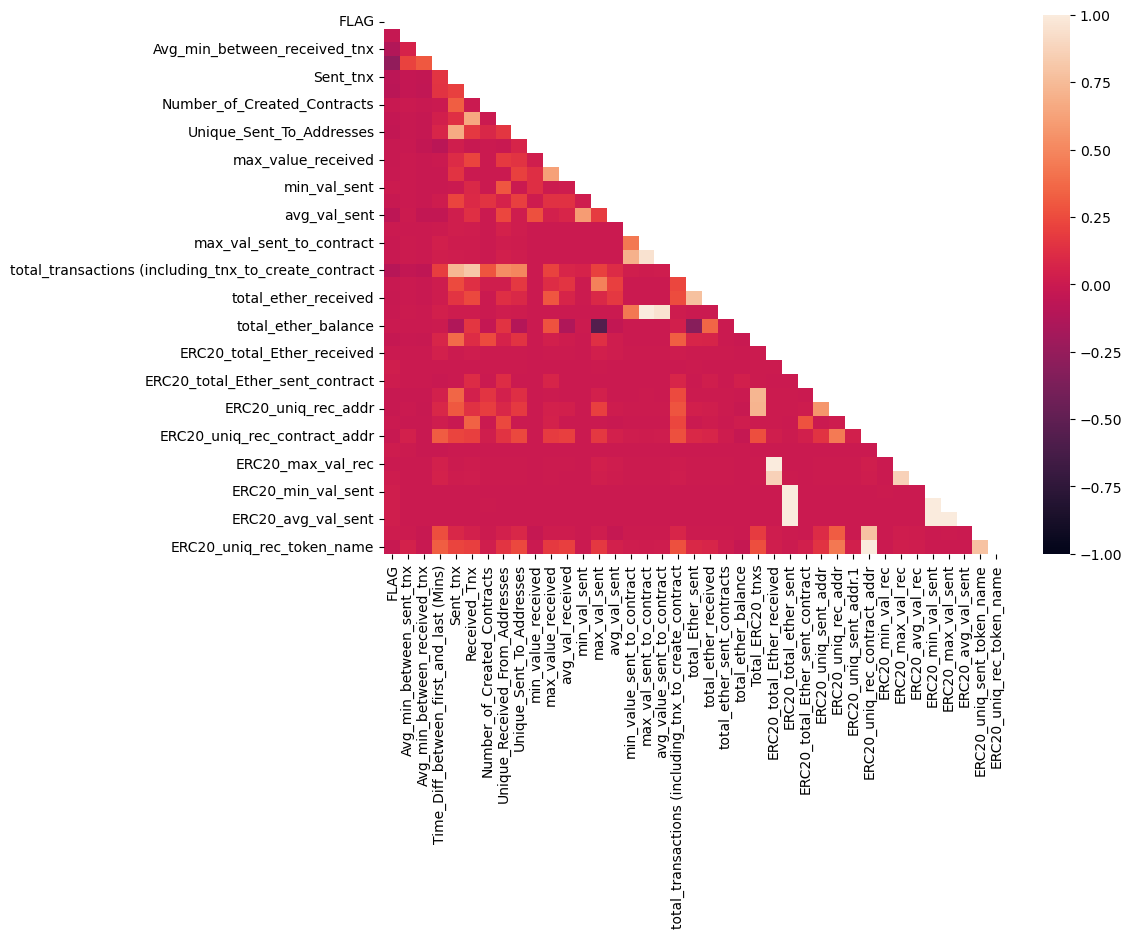

In [87]:
plt.figure(figsize=(10, 7))
numeric = df.select_dtypes(include=['number']).columns
corr = df[numeric].corr()
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr, mask=mask, annot=False, vmin=-1, vmax=1)
plt.show()

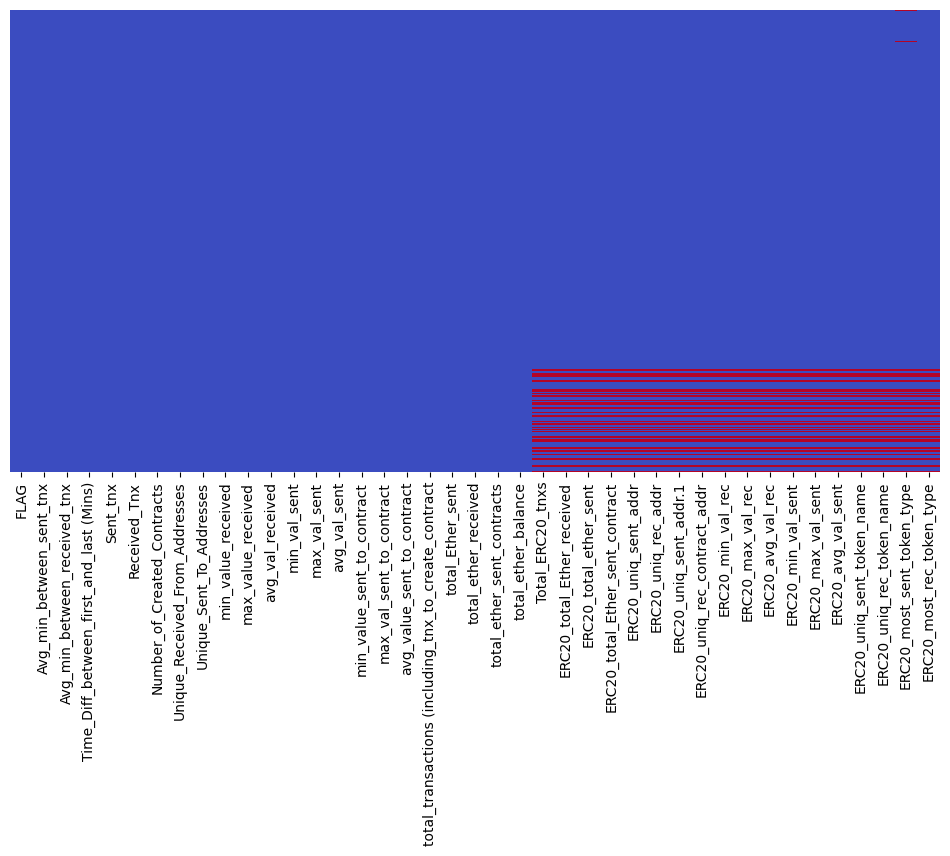

In [119]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cmap='coolwarm', cbar=False)
plt.yticks([])
plt.show()

In [89]:
print(f"Number of rows that has at least one missing value: {df.isnull().any(axis=1).sum()}")
missing_mask = df.isnull().any(axis=1)

Number of rows that has at least one missing value: 860


In [90]:
print(df.loc[missing_mask, 'FLAG'].value_counts())
print()
print(round(df.loc[missing_mask, 'FLAG'].value_counts(normalize=True), 2) * 100)

1    829
0     31
Name: FLAG, dtype: int64

1    96.0
0     4.0
Name: FLAG, dtype: float64


In [91]:
print(df['FLAG'].value_counts())
print()
print(round(df['FLAG'].value_counts(normalize=True), 2) * 100)

0    7662
1    2179
Name: FLAG, dtype: int64

0    78.0
1    22.0
Name: FLAG, dtype: float64


In [92]:
print(df[~missing_mask].shape)
sub_df = df[~missing_mask]

(8981, 41)


In [93]:
# Split the data into train and test set
X = sub_df.drop(columns='FLAG', axis=1)
y = sub_df['FLAG']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [94]:
print(f"Shape of X_train is {X_train.shape}")
print(f"Shape of y_train is {y_train.shape}")
print(f"Shape of X_test is {X_test.shape}")
print(f"Shape of y_test is {y_test.shape}")

Shape of X_train is (7184, 40)
Shape of y_train is (7184,)
Shape of X_test is (1797, 40)
Shape of y_test is (1797,)


In [95]:
encoder = TargetEncoder(cols=categories)
X_train_encoded = encoder.fit_transform(X_train, y_train)
X_test_encoded = encoder.transform(X_test)

In [96]:
y_test 

5397    0
96      0
8986    1
7705    1
1000    0
       ..
90      0
3310    0
2893    0
404     0
6195    0
Name: FLAG, Length: 1797, dtype: int64

In [97]:
train = pd.concat([X_train_encoded, y_train], axis=1)
test  = pd.concat([X_test_encoded, y_test], axis=1)

In [98]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from category_encoders import TargetEncoder

In [99]:
#model = IsolationForest(contamination=0.22, random_state=42)
#model.fit(train)


In [100]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from category_encoders import TargetEncoder

# Impute missing values (replace your dropping step)
df_imputed = df.copy()
numeric_cols = df_imputed.select_dtypes(include=['number']).columns
df_imputed[numeric_cols] = df_imputed[numeric_cols].fillna(0)
categorical_cols = ['ERC20_most_sent_token_type', 'ERC20_most_rec_token_type']
df_imputed[categorical_cols] = df_imputed[categorical_cols].fillna('Unknown')

In [101]:
df_imputed[categorical_cols]

,ERC20_most_sent_token_type,ERC20_most_rec_token_type
0,Cofoundit,Numeraire
1,Livepeer Token,Livepeer Token
2,None,XENON
3,Raiden,XENON
4,StatusNetwork,EOS
...,...,...
9836,,GSENetwork
9837,,Blockwell say NOTSAFU
9838,,Free BOB Tokens - BobsRepair.com
9839,Unknown,Unknown


In [102]:
# Split data
X = df_imputed.drop(columns='FLAG')
y = df_imputed['FLAG']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Encode categorical columns
encoder = TargetEncoder(cols=categorical_cols)
X_train_encoded = encoder.fit_transform(X_train, y_train)
X_test_encoded = encoder.transform(X_test)

# Scale features (important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

In [111]:
X_train_encoded

,Avg_min_between_sent_tnx,Avg_min_between_received_tnx,Time_Diff_between_first_and_last (Mins),Sent_tnx,Received_Tnx,Number_of_Created_Contracts,Unique_Received_From_Addresses,Unique_Sent_To_Addresses,min_value_received,max_value_received,...,ERC20_min_val_rec,ERC20_max_val_rec,ERC20_avg_val_rec,ERC20_min_val_sent,ERC20_max_val_sent,ERC20_avg_val_sent,ERC20_uniq_sent_token_name,ERC20_uniq_rec_token_name,ERC20_most_sent_token_type,ERC20_most_rec_token_type
625,6.44,3266.12,9817.67,3,3,0,3,3,1.990000,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000
1922,17415.12,48392.42,931014.72,9,16,0,7,5,0.038655,6.176138,...,0.000000,1.137182,0.379061,1.137182,1.137182,1.137182,1.0,2.0,0.055069,0.244474
6615,29.14,0.00,58.28,2,1,0,1,2,101.000000,101.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000
7277,86772.18,0.00,173544.37,2,1,0,1,2,2.095936,2.095936,...,0.151820,320.782834,107.049338,0.000000,0.000000,0.000000,0.0,3.0,0.000000,0.015873
5040,1126.46,1277.52,348261.82,164,128,0,13,79,0.001170,703.019662,...,0.000000,171304.100000,8063.214941,0.000000,99999.980000,5161.600510,19.0,26.0,0.163705,0.166979
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5734,0.00,16197.17,226760.43,0,14,1,6,0,0.000000,14.419115,...,0.518689,0.705159,0.611924,0.000000,0.000000,0.000000,0.0,2.0,0.000000,0.015873
5191,0.00,0.00,15369.12,1,1,0,1,1,2.000000,2.000000,...,0.000000,312.430205,50.497598,0.000000,0.000000,0.000000,0.0,7.0,0.000000,0.257485
5390,0.00,0.00,1.77,1,1,0,1,1,1.990000,1.990000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000
860,165.15,0.00,330.30,2,2,0,2,2,49.770407,51.229593,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000


In [112]:
# Train Logistic Regression
lr_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [113]:
# Predict and evaluate
lr_pred = lr_model.predict(X_test_scaled)
print("Logistic Regression Classification Report:")
print(classification_report(y_test, lr_pred, target_names=['Non-Fraud (0)', 'Fraud (1)']))

# Test accuracy
test_accuracy = (lr_pred == y_test).mean() * 100
print(f"Logistic Regression Test accuracy: {test_accuracy:.2f}%")

Logistic Regression Classification Report:
               precision    recall  f1-score   support

Non-Fraud (0)       0.99      1.00      0.99      1542
    Fraud (1)       0.99      0.97      0.98       427

     accuracy                           0.99      1969
    macro avg       0.99      0.99      0.99      1969
 weighted avg       0.99      0.99      0.99      1969

Logistic Regression Test accuracy: 99.14%


In [114]:
from sklearn.preprocessing import StandardScaler  # If not already imported
import joblib

# Assuming your scaler is named 'scaler' (from earlier code where you scaled X_train/X_test)
# If it's not, replace with your scaler's variable name
joblib.dump(lr_model, 'logistic_regression_model.joblib')
joblib.dump(scaler, 'scaler.joblib')  # Save the scaler for future preprocessing

# Alternatively, use pickle if you prefer .pkl files
import pickle
with open('logistic_regression_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

In [115]:
X_test.iloc[0]
X_test_scaled

array([[-0.15672713, -0.26315005,  0.33403502, ...,  0.02957163,
         1.94408003,  0.17651117],
       [-0.09896169, -0.31896873, -0.64759575, ..., -0.2088184 ,
         1.94408003,  2.10605882],
       [-0.23003058, -0.35594087, -0.67692818, ..., -0.2684159 ,
        -0.57925717, -0.61606087],
       ...,
       [-0.22972342, -0.35585219, -0.67687738, ..., -0.2684159 ,
        -0.57925717, -0.61606087],
       [-0.23755786, -0.35594087, -0.67783951, ..., -0.2684159 ,
        -0.57925717, -0.61606087],
       [-0.23779933, -0.24428586, -0.32621527, ..., -0.2088184 ,
        -0.57925717, -0.57285262]])

In [116]:
# Test loop for indices 500-700
i=0
example_row_scaled = X_test_scaled[i].reshape(1, -1)  # Use scaled features
prediction = lr_model.predict(example_row_scaled)
prob = lr_model.predict_proba(example_row_scaled)[0]  # Probability of each class
true_label = y_test.iloc[i]
print(f"Index: {i}")
print(f"Prediction: {'Fraud (1)' if prediction[0] == 1 else 'Non-Fraud (0)'}")
print(f"Probability (Non-Fraud, Fraud): [{prob[0]:.4f}, {prob[1]:.4f}]")
print(f"True label (FLAG): {true_label} (1=fraud, 0=non-fraud)")
print("\n")

# Feature importance (coefficients)
feature_importance = pd.DataFrame({
    'Feature': X_train_encoded.columns,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)
print("Top 10 Feature Importances:")
print(feature_importance)

Index: 0
Prediction: Fraud (1)
Probability (Non-Fraud, Fraud): [0.0001, 0.9999]
True label (FLAG): 1 (1=fraud, 0=non-fraud)


Top 10 Feature Importances:
                                              Feature  Coefficient
38                         ERC20_most_sent_token_type     5.132306
39                          ERC20_most_rec_token_type     3.088373
3                                            Sent_tnx    -2.192343
2             Time_Diff_between_first_and_last (Mins)    -1.723231
26                               ERC20_uniq_sent_addr    -1.281792
17  total_transactions (including_tnx_to_create_co...    -1.197957
22                                   Total_ERC20_tnxs    -1.162766
7                            Unique_Sent_To_Addresses    -0.868644
36                         ERC20_uniq_sent_token_name     0.579781
37                          ERC20_uniq_rec_token_name     0.552964
27                                ERC20_uniq_rec_addr     0.499697
1                        Avg_min_between_r

In [117]:
# Test loop for indices 500-700
for i in range(1000,1010):
    example_row_scaled = X_test_scaled[i].reshape(1, -1)  # Use scaled features
    prediction = lr_model.predict(example_row_scaled)
    prob = lr_model.predict_proba(example_row_scaled)[0]  # Probability of each class
    true_label = y_test.iloc[i]
    print(f"Index: {i}")
    print(f"Prediction: {'Fraud (1)' if prediction[0] == 1 else 'Non-Fraud (0)'}")
    print(f"Probability (Non-Fraud, Fraud): [{prob[0]:.4f}, {prob[1]:.4f}]")
    print(f"True label (FLAG): {true_label} (1=fraud, 0=non-fraud)")
    print("\n")

# Feature importance (coefficients)
feature_importance = pd.DataFrame({
    'Feature': X_train_encoded.columns,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)
print("Top 10 Feature Importances:")
print(feature_importance)

Index: 1000
Prediction: Non-Fraud (0)
Probability (Non-Fraud, Fraud): [0.9908, 0.0092]
True label (FLAG): 0 (1=fraud, 0=non-fraud)


Index: 1001
Prediction: Non-Fraud (0)
Probability (Non-Fraud, Fraud): [0.9889, 0.0111]
True label (FLAG): 0 (1=fraud, 0=non-fraud)


Index: 1002
Prediction: Non-Fraud (0)
Probability (Non-Fraud, Fraud): [0.9963, 0.0037]
True label (FLAG): 0 (1=fraud, 0=non-fraud)


Index: 1003
Prediction: Fraud (1)
Probability (Non-Fraud, Fraud): [0.0000, 1.0000]
True label (FLAG): 1 (1=fraud, 0=non-fraud)


Index: 1004
Prediction: Non-Fraud (0)
Probability (Non-Fraud, Fraud): [0.9890, 0.0110]
True label (FLAG): 0 (1=fraud, 0=non-fraud)


Index: 1005
Prediction: Non-Fraud (0)
Probability (Non-Fraud, Fraud): [0.9929, 0.0071]
True label (FLAG): 0 (1=fraud, 0=non-fraud)


Index: 1006
Prediction: Non-Fraud (0)
Probability (Non-Fraud, Fraud): [0.9899, 0.0101]
True label (FLAG): 0 (1=fraud, 0=non-fraud)


Index: 1007
Prediction: Non-Fraud (0)
Probability (Non-Fraud, Fraud): [0.